In [1]:
%matplotlib inline

# External Modules
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets

Axes(0.125,0.11;0.775x0.77)


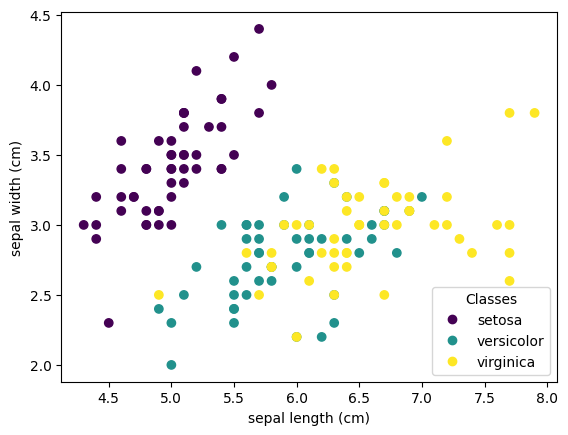

In [3]:
iris = datasets.load_iris()

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

print(ax)

In [4]:
def logistic_model(theta):
    ''' Combines given arguments of logistic function and returns it as a function
    
    Args:
        theta: vector of length k+1, contains theta_0, theta_1, ... , theta_k
        
    Returns:
        lambda that models a logistic function based on theta and x, where x is a batch of feature vectors with shape (N,k)
    ''' 

    # für einheitliche Formatierung des Theta-Vektors
    theta = np.asarray(theta).reshape(-1)

    def h_theta(x):
        X = np.asarray(x)

        # für den Fall eines einzelnen Datenpunktes
        if X.ndim == 1:
            X = X.reshape(1, -1)

        # definiert, was Anzahl der Spalten bzw Zeilen ist
        N, k = X.shape

        X_tilde = np.hstack([np.ones((N, 1)), X]) # np.hstack = horizontaler Stack   # irgendwann wann gehen die Namen für x aus (groß X, X_tilde, X_dach)

        # Multipliziert die Thetas mit den x
        z = X_tilde @ theta # @ = Matrix Multiplier

        # Formel:
        return 1 / (1 + np.exp(-z))
        
    return h_theta
    
def grad_logistic_model(x,theta):
    ''' Computes for a given set of feature vectors x the gradient of the logistic_model at the given theta values
    
    Args:
        x : matrix of shape (N,k) containing x_i,j as the j-th feature of the i-th datapoint 
        theta: vector of length k+1, contains theta_0, theta_1, ... , theta_k
        
    Returns:
        gradient matrix G with shape (N,k+1) and G_i,j = del h_theta(x^{(i)}) / del theta_j 
    ''' 

    X = np.asarray(x)
    theta = np.asarray(theta).reshape(-1)

    if X.ndim == 1:
        X = X.reshape(1, -1)
    N, k = X.shape
    X_tilde = np.hstack([np.ones((N, 1)), X])

    h = logistic_model(theta)
    h_vals = h(X)

    # Ableitung
    deriv = (h_vals * (1 - h_vals)).reshape(-1, 1)

    # Gradient pro Datenpunkt
    Grad = deriv * X_tilde   # elementweise Multiplikation (Kettenregel)
    return Grad

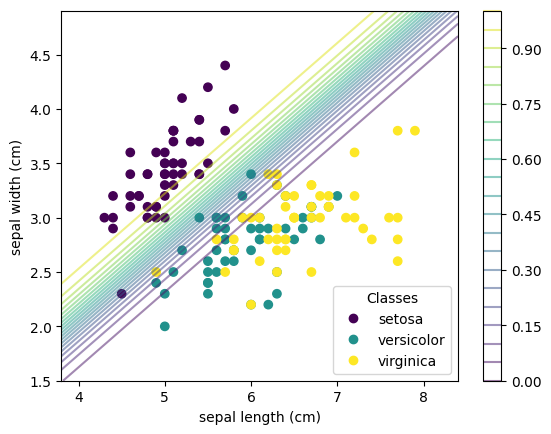

In [5]:
# Scatterplot der ersten beiden Features (s.o.)
fig, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names,
    loc="lower right", title="Classes"
)

# Beispiel-Theta 
theta = np.array([4.5, -4.5, 6.5]) # durchprobiert
h = logistic_model(theta)

# für die Konturlinien
x_min, x_max = iris.data[:, 0].min() - 0.5, iris.data[:, 0].max() + 0.5
y_min, y_max = iris.data[:, 1].min() - 0.5, iris.data[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
zz = h(grid_points).reshape(xx.shape)

# Konturplot
contour = ax.contour(xx, yy, zz, levels=20, alpha=0.5)

# Farbleiste an der Seite
ax.figure.colorbar(contour, ax=ax)

plt.show()


In [6]:
def mse_cost_function(x, y, model_fct):
    ''' Implements MSE cost function as a function J(theta) on given tranings data 
    
    Args:
        x: matrix of shape (N,k) of N feature vectors of length k
        y: vector of shape (N,) with ground truth values y 
        model_fct: lambda that creates the model h_theta for a given set of parameters
        
    Returns:
        lambda J(theta) that models the mse cost function
    '''
    X = np.asarray(x)
    Y = np.asarray(y).reshape(-1)

    N = X.shape[0]  # Anzahl Datenpunkte
    
    def J(theta):       
        # erzeugt das Modell h_theta(x)
        h = model_fct(theta)
        
        # Modellvorhersagen berechnen
        preds = h(X)   # (N,)
        
        # Kosten berechnen
        diff = preds - Y
        
        # MSE Kostenfunktion
        cost = np.sum(diff ** 2) / (2 * N)
        return cost
    
    return J

def grad_mse_cost_function(x,y,theta,model_fct,model_grad_fct):
    ''' Computes the gradient of the MSE cost function for a given dataset x,y and parameters theta of the model created by model_fct
    
    Args:
        x: matrix of shape (N,k) of N feature vectors of length k
        y: vector of shape (N,) with ground truth values y 
        theta: vecotr of shape (k+1) containing the parameters theta_0, ... , theta_k
        model_fct: lambda that creates the model h_theta for a given set of parameters
        model_grad_fct: lambda that computes the gradient of the model, i.e. that returns del h_theta(x^{(i)}) / del theta_j
        
    Returns:
        vector G of shape (k+1,) with G_{j} = del J(theta) / del theta_j, with J being the mse cost function for x,y
    '''
    X = np.asarray(x)
    Y = np.asarray(y).reshape(-1)
    N = X.shape[0]

    h = model_fct(theta)
    preds = h(X)

    # Gradient des Modells holen und Ableitungen von h(x) berechnen
    grad_model = model_grad_fct(X, theta)  
    
    diff = preds - Y                      

    # Gradient der Kosten berechnen: Gesamtableitung von J(Theta)
    grad_J = (diff.reshape(-1, 1) * grad_model).mean(axis=0)
    
    return grad_J

def bce_cost_function(x, y, model_fct,eps=1E-16):
    ''' Implements BCE cost function as a function J(theta) on given tranings data 
    
    Args:
        x: matrix of shape (N,k) of N feature vectors of length k
        y: vector of shape (N,) with ground truth values y 
        model_fct: lambda that creates the model h_theta for a given set of parameters
        eps: numerical shift for the numerical stability of the logarithm, optional, default: 1E-16
        
    Returns:
        lambda J(theta) that models the bce cost function
    '''
    X = np.asarray(x)
    Y = np.asarray(y).reshape(-1)
    N = X.shape[0]

    def J(theta):
        h = model_fct(theta)
        preds = h(X)
        
        # Numerische Stabilität: damit ln(0) vermieden wird
        preds = np.clip(preds, eps, 1 - eps)
        
        # BCE Kostenfunktion
        cost = -np.mean(Y * np.log(preds) + (1 - Y) * np.log(1 - preds))
        return cost
    
    return J

def grad_bce_cost_function(x,y,theta,model_fct,model_grad_fct,eps=1E-16):
    ''' Computes the gradient of the BCE cost function for a given dataset x,y and parameters theta of the model created by model_fct
    
    Args:
        x: matrix of shape (N,k) of N feature vectors of length k
        y: vector of shape (N,) with ground truth values y 
        theta: vecotr of shape (k+1) containing the parameters theta_0, ... , theta_k
        model_fct: lambda that creates the model h_theta for a given set of parameters
        model_grad_fct: lambda that computes the gradient of the model, i.e. that returns del h_theta(x^{(i)}) / del theta_j
        eps: numerical shift for the numerical stability of the logarithm, optional, default: 1E-16
        
    Returns:
        vector G of shape (k+1,) with G_{j} = del J(theta) / del theta_j, with J being the bce cost function for x,y
    '''
    X = np.asarray(x)
    Y = np.asarray(y).reshape(-1)
    N = X.shape[0]
    
    h = model_fct(theta)
    preds = h(X)
    
    # Numerische Stabilität 
    preds = np.clip(preds, eps, 1 - eps)

    grad_model = model_grad_fct(X, theta) 
    diff = preds - Y  
    grad_J = (diff.reshape(-1, 1) * grad_model).mean(axis=0)
    
    return grad_J

In [7]:
def update_theta(x, y, theta, alpha, cost_grad, model_fct, model_grad_fct):
    ''' Updates learnable parameters theta 
    
    The update is done by calculating the partial derivities of 
    the cost function including the model. The gradient
    is computed by the given cost_grad method and scaled by a scalar and
    subtracted from the given theta values.
    
    Args:
        x: matrix of shape (N,k) of x values
        y: array of y values of shape (N,) corresponding to x
        theta: vector of current theta values
        alpha: learning_rate, value to scale the negative gradient 
        cost_grad: function that computes the gradient of the utilized cost function
        model_fct: function that returns the model to be optimized
        model_grad_fct: function that computes the gradient of the utilized model
        
    Returns:
        t: vector of updated thetas
    '''
    
    theta = np.asarray(theta).reshape(-1)

    # mit der gegebenen Kostenfunktion Gradient berechnen
    grad = cost_grad(x, y, theta, model_fct, model_grad_fct)

    # Formel: Gradient descent
    theta_new = theta - alpha * grad

    return theta_new

In [8]:
def gradient_descent(x, y, num_parameters, model_fct, model_grad_fct, cost_fct, cost_grad_fct, epsilon=1E-4, alpha=0.0001, verbose=False, max_iterations=10000):
    ''' Minimize theta values of a linear model based on MSE cost function
    
    Args:
        x: matrix of shape (N,k) of x values from the data set
        y: vector of shape (N,) of y values from the data set
        num_parameters: number of parameters of the model (here k+1)
        model_fct: lambda that implements the model h_theta for a given vector of parameters theta
        model_grad_fct: lambda that computs the derivative of the model as matrix of shape (N,num_parameters) with G_{i,j} = del h_theta(x^{(i)}) / del theta_j 
        cost_fct: lambda that implements the utilized cost function J(theta) for the given model
        cost_grad_fct: lambda that computs the derivative of the cost as vector of shape (num_parameters) with G_{j} = del J(theta) / del theta_j
        epsilon: scalar, control accuracy of the method
        alpha: scalar, learning rate, scales the negative gradient
        verbose: boolean, print addition information 
        max_iterations: scalar, number of maximal theta updates
        
    Returns:
    
        costs: list oft costs, one value for each iteration.
        ts: list of theta values, one value for each iteration
    '''

    x = np.asarray(x)
    y = np.asarray(y).reshape(-1)

    # random startwert wählen
    theta = np.random.randn(num_parameters)

    # Kostenfunktion erzeugen
    J = cost_fct(x, y, model_fct)
    cost_prev = J(theta)

    # Historie der Kosten
    costs = [cost_prev]
    thetas = [theta.copy()]

    for i in range(max_iterations):
        # Theta updaten
        theta = update_theta(x, y, theta, alpha, cost_grad_fct, model_fct, model_grad_fct)

        # neuen Kosten berechnen
        current_cost = J(theta)

        # der Historie hinzufügen
        costs.append(current_cost)
        thetas.append(theta.copy())

        # Abbruchbedingung
        if abs(cost_prev - current_cost) < epsilon:   
            break

        cost_prev = current_cost
        
    if verbose:
                grad = cost_grad_fct(x, y, theta, model_fct, model_grad_fct)
                print("final result")
                print(f"\tcost: {current_cost}")
                print(f"\tθ: {theta}")
                print(f"\tnumber of iterations: {i+1}")
                print(f"\tgradient norm: {np.linalg.norm(grad)}")
    return costs, thetas

In [55]:
x = iris.data[:, :2]

mask = iris.target < 2
x = x[mask]
y = iris.target[mask]

cost_hist_bce, t_hist_bce = gradient_descent(x, y,x.shape[1]+1,
                                     logistic_model,
                                     grad_logistic_model,
                                     bce_cost_function,
                                     grad_bce_cost_function, epsilon=1e-5, alpha=0.01, verbose=True,max_iterations=1000)

cost_hist_mse, t_hist_mse = gradient_descent(x, y,x.shape[1]+1,
                                     logistic_model,
                                     grad_logistic_model,
                                     mse_cost_function,
                                     grad_mse_cost_function, epsilon=1e-6, alpha=0.1, verbose=True,max_iterations=1000)

# eine Iteration scheint mir so wenig: Hab ein wenig mit den Epsilons rumgespielt, aber bei einem Punkt springt er schnell von 1 Iteration zu 1000. Selten kriege ich auch bei den vorgegebenen Epsilons
# mehr als eine Iteration (aber trotzdem meist unter 30). Vielleicht liegt es am Datensatz oder an meiner Funktion. Ich finds nur komisch
# habe hier sehr viel rum experimentiert mit den Parametern, sehr viele verschiedene Ergebnisse

final result
	cost: 0.44383321925442976
	θ: [ 1.0821549   0.48601526 -1.18997319]
	number of iterations: 1000
	gradient norm: 0.0363601231957542
final result
	cost: 0.040733741222515135
	θ: [-0.27730221  1.03153415 -1.71485389]
	number of iterations: 1000
	gradient norm: 0.02175074002406575


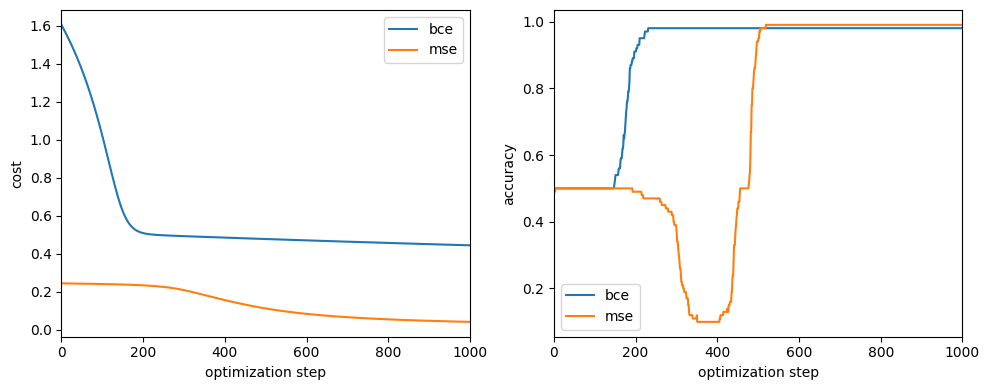

In [56]:
def compute_accuracy(x,y,theta,model_fct):
    ''' Computes the accuracy of the model defined by the given set of parameters on the given dataset
    
    Args:
        x: matrix of shape (N,k) of x values from the data set
        y: vector of shape (N,) of y values from the data set
        theta: vector of shape (k+1,) containing the parameters of the model
        model_fct: lambda that implements the model h_theta for a given vector of parameters theta
        
    Returns:
        accuracy: scalar, accuracy of the model
    '''
    X = np.asarray(x)
    Y = np.asarray(y).reshape(-1)
    
    h = model_fct(theta)
    preds = h(X)
    
    # Wahrscheinlichkeiten in Klassen umwandeln
    y_pred = (preds >= 0.5).astype(int)
    
    # Accuracy
    accuracy = np.mean(y_pred == Y)
    
    return accuracy
    
acc_hist_bce = [compute_accuracy(x, y, t, logistic_model) for t in t_hist_bce]
acc_hist_mse = [compute_accuracy(x, y, t, logistic_model) for t in t_hist_mse]

# Plot: Kostenverlauf
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(cost_hist_bce, label='bce')
plt.plot(cost_hist_mse, label='mse')
plt.xlabel("optimization step")
plt.ylabel("cost")
plt.legend()
plt.xlim(0, 1000)

# Plot: Accuracy-Verlauf
plt.subplot(1,2,2)
plt.plot(acc_hist_bce, label='bce')
plt.plot(acc_hist_mse, label='mse')
plt.xlabel("optimization step")
plt.ylabel("accuracy")
plt.legend()
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

final result
	cost: 0.3991076564634289
	θ: [ 0.92558284  0.30736197 -1.51530359]
	number of iterations: 1000
	gradient norm: 0.06430232760802801


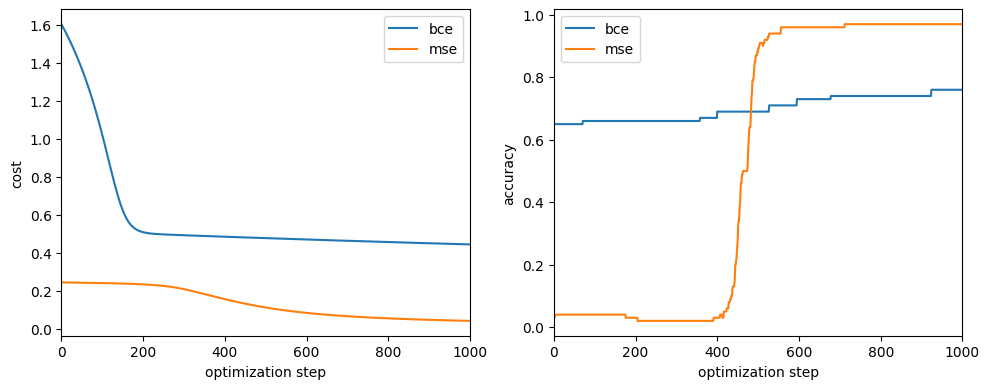

In [57]:
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x_norm = (x - x_mean) / x_std

cost_hist_bce_norm, t_hist_bce_norm = gradient_descent(
    x_norm, y, x_norm.shape[1]+1,
    logistic_model,
    grad_logistic_model,
    bce_cost_function,
    grad_bce_cost_function,
    epsilon=1e-6,
    alpha=0.01,
    verbose=True,
    max_iterations=1000
)

acc_hist_bce = [compute_accuracy(x_norm, y, t, logistic_model) for t in t_hist_bce]
acc_hist_mse = [compute_accuracy(x_norm, y, t, logistic_model) for t in t_hist_mse]

# Plot: Kostenverlauf
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(cost_hist_bce, label='bce')
plt.plot(cost_hist_mse, label='mse')
plt.xlabel("optimization step")
plt.ylabel("cost")
plt.legend()
plt.xlim(0, 1000)

# Plot: Accuracy-Verlauf
plt.subplot(1,2,2)
plt.plot(acc_hist_bce, label='bce')
plt.plot(acc_hist_mse, label='mse')
plt.xlabel("optimization step")
plt.ylabel("accuracy")
plt.legend()
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

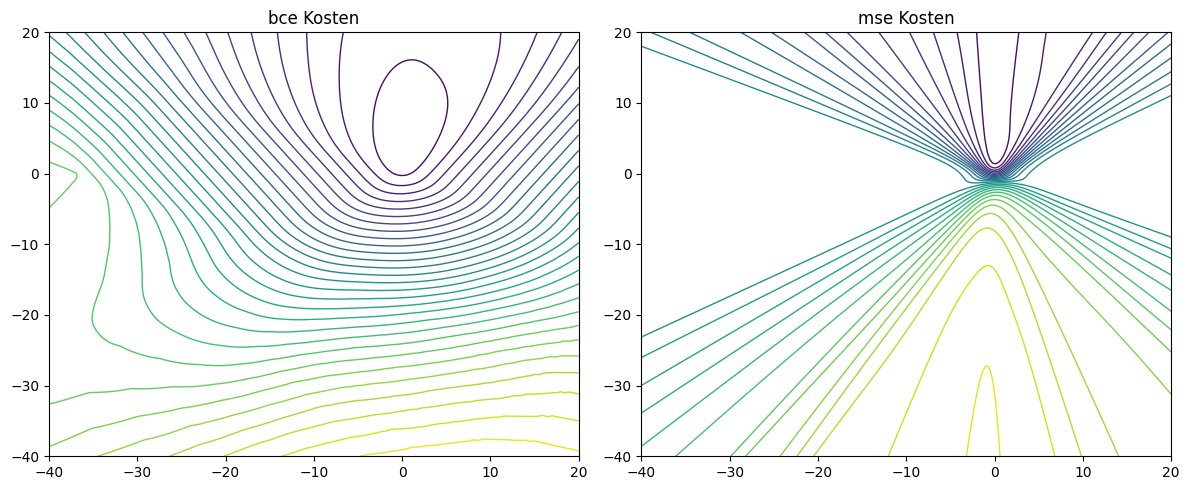

In [58]:
X_1 = x_norm[:, [0]]  # nur erstes Feature
Y = y

theta0_range = np.linspace(-40, 20, 200)
theta1_range = np.linspace(-40, 20, 200)
T0, T1 = np.meshgrid(theta0_range, theta1_range)

J_bce = np.zeros_like(T0)
J_mse = np.zeros_like(T0)

# Kostenfunktionen erzeugen
J_bce_fct = bce_cost_function(X_1, Y, logistic_model)
J_mse_fct = mse_cost_function(X_1, Y, logistic_model)

# Kostenwerte für jedes Gitter 
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta = np.array([T0[i, j], T1[i, j]])
        J_bce[i, j] = J_bce_fct(theta)
        J_mse[i, j] = J_mse_fct(theta)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# BCE-Konturen
cs1 = ax[0].contour(T0, T1, J_bce, levels=30, linewidths=1)
ax[0].set_title("bce Kosten")
ax[0].set_xlim(-40, 20)  
ax[0].set_ylim(-40, 20) 

# MSE-Konturen
cs2 = ax[1].contour(T0, T1, J_mse, levels=30, linewidths=1)
ax[1].set_title("mse Kosten")
ax[1].set_xlim(-40, 20)  
ax[1].set_ylim(-40, 20) 

plt.tight_layout()
plt.show()


In [13]:
def linear_model(theta):
    ''' Combines given arguments of linear function and returns it as a function
    
    Args:
        theta: vector of length k+1, contains theta_0, theta_1, ... , theta_k
        
    Returns:
        lambda that models a linear function based on theta and x
    ''' 
    theta = np.asarray(theta).reshape(-1)

    def h_theta(x):
        X = np.asarray(x)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        N = X.shape[0]

        X_tilde = np.hstack([np.ones((N, 1)), X])
        return X_tilde @ theta  # lineare Kombination

    return h_theta
    
def grad_linear_model(x,theta):
    ''' Computes for a given set of feature vectors x the gradient of the logistic_model at the given theta values
    
    Args:
        x : matrix of shape (N,k) containing x_i,j as the j-th feature of the i-th datapoint
        theta: vector of length k+1, contains theta_0, theta_1, ... , theta_k
        
    Returns:
        gradient matrix G with shape (N,k+1) and G_i,j = del h_theta(x^{(i)}) / del theta_j 
    ''' 
    X = np.asarray(x)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    N = X.shape[0]

    X_tilde = np.hstack([np.ones((N, 1)), X])
    return X_tilde

from sklearn.datasets import load_diabetes

# Daten laden
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

In [17]:
costs, thetas = gradient_descent(
    x, y,
    num_parameters=x.shape[1] + 1,
    model_fct=linear_model,
    model_grad_fct=grad_linear_model,
    cost_fct=mse_cost_function,
    cost_grad_fct=grad_mse_cost_function,
    alpha=0.001,
    epsilon=0.001,
    verbose=True,
    max_iterations=1000
)

final result
	cost: 4542.612204839029
	θ: [ 9.57607170e+01  4.40688886e-01  1.74600005e+00  2.77032775e+00
 -8.20967658e-01 -4.73833447e-02 -1.80537168e-01 -9.84625860e-01
  2.64368191e+00  2.70686627e-01  7.92985871e-02]
	number of iterations: 1000
	gradient norm: 56.54439685313475


In [18]:
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x_scaled = (x - x_mean) / x_std

costs_scaled, thetas_scaled = gradient_descent(
    x_scaled, y,
    num_parameters=x.shape[1] + 1,
    model_fct=linear_model,
    model_grad_fct=grad_linear_model,
    cost_fct=mse_cost_function,
    cost_grad_fct=grad_mse_cost_function,
    alpha=0.001,
    epsilon=1e-6,
    verbose=True,
    max_iterations=1000
)

final result
	cost: 3132.7150153225357
	θ: [95.39095432  1.93559763 -4.80456453 19.06744912 11.44661545 -1.57009989
 -0.83664363 -8.70248356  6.99540954 15.39595116  6.50916055]
	number of iterations: 1000
	gradient norm: 58.11675430824522


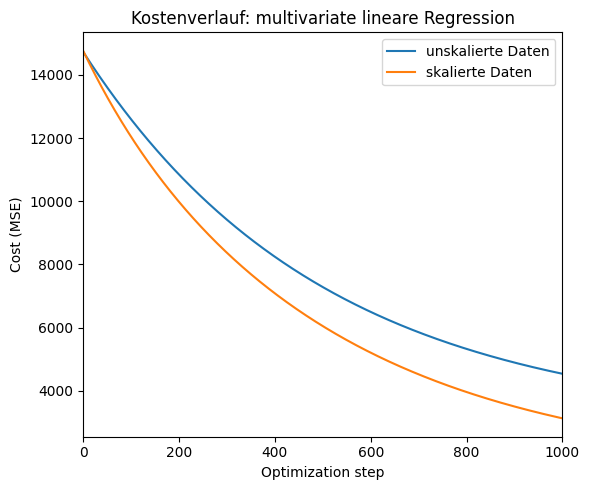

In [19]:
plt.figure(figsize=(6, 5))

plt.plot(costs, label='unskalierte Daten')
plt.plot(costs_scaled, label='skalierte Daten')
plt.xlabel("Optimization step")
plt.ylabel("Cost (MSE)")
plt.title("Kostenverlauf: multivariate lineare Regression")
plt.legend()
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()